# Stage 2: Feature Engineering & Player Profiling

Goal: turn raw StatsBomb event data into a single player profile matrix — one row per player, one column per feature — ready for clustering.

**Scope:** male club competitions only. International tournaments (World Cup etc.) and women's competitions are excluded.

**Pipeline:**
1. Identify which competition-seasons to process
2. Calculate minutes played per player per competition-season
3. Compute raw feature counts per player per competition-season
4. Pool club competition-seasons per player and apply the 90-minute minimum
5. Convert counts to per-90 rates
6. Z-score context-sensitive features against competition-season peer groups
7. Output the player profile matrix

In [1]:
import pandas as pd
import statsbombpy.sb as sb

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Competition-season manifest

We build a filtered list of competition-seasons upfront. This manifest drives every loop later — if a competition-season isn't in this list, we never touch it.

Two filters:
- `competition_gender == 'male'` — exclude women's competitions
- Exclude national team tournaments — these are international competitions where players represent countries, not clubs. We flag them but don't include them in the club profile pipeline.

In [2]:
# National team tournaments — players represent countries, not clubs.
# We exclude these from the club pipeline entirely for now.
INTERNATIONAL_COMPS = {
    'FIFA World Cup',
    'UEFA Euro',
    'Copa America',
    'African Cup of Nations',  # StatsBomb spells it with an 'n' — not 'Africa Cup'
    'FIFA U20 World Cup',
    'Gold Cup',
    'Olympic Games',
}

def competition_era(season_name):
    # season_name is either 'YYYY/YYYY' or 'YYYY' — first 4 chars is always the start year
    start_year = int(str(season_name)[:4])
    if start_year < 2000:
        return 'pre-2000'
    elif start_year < 2010:
        return '2000-2010'
    else:
        return 'post-2010'

all_competitions = sb.competitions()

manifest = (
    all_competitions[
        (all_competitions['competition_gender'] == 'male') &
        (~all_competitions['competition_name'].isin(INTERNATIONAL_COMPS))
    ]
    .copy()
    [['competition_id', 'competition_name', 'season_id', 'season_name', 'country_name']]
    .sort_values(['competition_name', 'season_name'])
    .reset_index(drop=True)
)

manifest['era'] = manifest['season_name'].apply(competition_era)

print(f"Competition-seasons to process: {len(manifest)}")
print()
print(manifest['era'].value_counts().to_string())
print()
manifest

Competition-seasons to process: 54

era
post-2010    29
pre-2000     13
2000-2010    12



/Users/kareemel-wakeel/Football Analytics/football-scouting-tool/venv/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,competition_name,season_id,season_name,country_name,era
0,9,1. Bundesliga,27,2015/2016,Germany,post-2010
1,9,1. Bundesliga,281,2023/2024,Germany,post-2010
2,16,Champions League,276,1970/1971,Europe,pre-2000
3,16,Champions League,71,1971/1972,Europe,pre-2000
4,16,Champions League,277,1972/1973,Europe,pre-2000
5,16,Champions League,76,1999/2000,Europe,pre-2000
6,16,Champions League,44,2003/2004,Europe,2000-2010
7,16,Champions League,37,2004/2005,Europe,2000-2010
8,16,Champions League,39,2006/2007,Europe,2000-2010
9,16,Champions League,41,2008/2009,Europe,2000-2010


## 2. Minutes played

StatsBomb doesn't give us minutes played directly. We derive it from two event types:

- **Starting XI** — one event per team at kickoff; contains a nested list of all 11 starters
- **Substitution** — fires when a player is replaced; the event's player is coming *off*, `substitution_replacement` is coming *on*

Rules:
- Starter with no substitution → played full match duration
- Starter who was subbed → played 0 to substitution minute
- Substitute → played from their on-minute to match end
- Match duration = max minute in periods 1 & 2 (captures injury time naturally)

Known limitation: red cards don't generate a Substitution event, so dismissed players will have their minutes slightly overcounted. This is rare enough not to affect profiles materially.

In [3]:
def get_player_minutes(match_id):
    """Returns a DataFrame of player_id, player_name, team_name, minutes_played for one match."""
    events = sb.events(match_id=match_id)

    match_duration = events[events['period'] <= 2]['minute'].max()

    # substitution_replacement is a name string in statsbombpy — not a dict.
    # Build a name→id lookup from all events so we can resolve substitute IDs.
    name_to_id = (
        events.dropna(subset=['player_id'])
        [['player', 'player_id']]
        .drop_duplicates('player')
        .set_index('player')['player_id']
        .to_dict()
    )

    players = {}

    # --- Starters ---
    for _, row in events[events['type'] == 'Starting XI'].iterrows():
        for p in row['tactics']['lineup']:
            pid = p['player']['id']
            players[pid] = {
                'player_id':    pid,
                'player_name':  p['player']['name'],
                'team_name':    row['team'],
                'start_minute': 0,
                'end_minute':   match_duration,
            }

    # --- Substitutions ---
    for _, row in events[events['type'] == 'Substitution'].iterrows():
        minute = row['minute']

        # Cap the outgoing player's time
        pid_off = row['player_id']
        if pid_off in players:
            players[pid_off]['end_minute'] = minute

        # Incoming player: resolve ID from name lookup
        incoming_name = row['substitution_replacement']
        pid_on = name_to_id.get(incoming_name)
        if pid_on is not None:
            players[pid_on] = {
                'player_id':    pid_on,
                'player_name':  incoming_name,
                'team_name':    row['team'],
                'start_minute': minute,
                'end_minute':   match_duration,
            }

    df = pd.DataFrame(players.values())
    df['minutes_played'] = df['end_minute'] - df['start_minute']
    return df[['player_id', 'player_name', 'team_name', 'minutes_played']]


# --- Test on one match ---
test_matches = sb.matches(competition_id=11, season_id=4)  # La Liga 2018/19
test_match_id = test_matches['match_id'].iloc[0]

minutes_df = get_player_minutes(test_match_id)
print(f"Match ID: {test_match_id}")
print(f"Players tracked: {len(minutes_df)}")
print(f"Total player-minutes: {minutes_df['minutes_played'].sum()}")
print()
minutes_df.sort_values('minutes_played', ascending=False)

/Users/kareemel-wakeel/Football Analytics/football-scouting-tool/venv/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Users/kareemel-wakeel/Football Analytics/football-scouting-tool/venv/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Match ID: 15978
Players tracked: 28
Total player-minutes: 2046



,player_id,player_name,team_name,minutes_played
0,6694.0,Gerónimo Rulli,Real Sociedad,93
10,6695.0,Juan Miguel Jiménez López,Real Sociedad,93
21,5246.0,Luis Alberto Suárez Díaz,Barcelona,93
19,5503.0,Lionel Andrés Messi Cuccittini,Barcelona,93
17,6379.0,Sergi Roberto Carnicer,Barcelona,93
16,5470.0,Ivan Rakitić,Barcelona,93
15,5211.0,Jordi Alba Ramos,Barcelona,93
1,6605.0,Joseba Zaldúa Bengoetxea,Real Sociedad,93
13,5213.0,Gerard Piqué Bernabéu,Barcelona,93
11,20055.0,Marc-André ter Stegen,Barcelona,93


## 3. Feature extraction — raw counts per match

For each match we compute raw counts per player (passes attempted, tackles, xG, etc.). We accumulate these across all matches, then divide by total minutes once at the end. This ensures a player who plays 1,800 minutes across 20 matches is treated consistently with one who plays 90 minutes in a single match.

**Set piece exclusion:** Open play passes have `pass_type == NaN`. Set pieces (`'Corner'`, `'Free Kick'`, `'Throw-in'`, `'Kick Off'`) are excluded from all passing features.

**Progressive passes:** StatsBomb doesn't provide this as a column. We compute it from coordinates: a pass is progressive if it moves the ball at least 30% closer to the centre of the opponent's goal line (x=120, y=40), and the end location is closer to goal than the start. This is the standard approximation used across football analytics.

**xG:** Provided directly by StatsBomb as `shot_statsbomb_xg` — no computation needed.

In [4]:
import numpy as np

# StatsBomb pitch: x = 0 (own goal) → 120 (opponent goal), y = 0 → 80
# Opponent goal centre is at (120, 40)
GOAL_X, GOAL_Y = 120.0, 40.0

def distance_to_goal(x, y):
    return np.sqrt((GOAL_X - x) ** 2 + (GOAL_Y - y) ** 2)

def is_progressive_pass(row):
    """True if the pass moves the ball ≥30% closer to the opponent's goal (open play only)."""
    try:
        sx, sy = row['location']
        ex, ey = row['pass_end_location']
        start_dist = distance_to_goal(sx, sy)
        end_dist   = distance_to_goal(ex, ey)
        return (start_dist > 0) and (end_dist < start_dist * 0.7)
    except (TypeError, KeyError):
        return False

def is_progressive_carry(row):
    """True if the carry moves the ball ≥30% closer to the opponent's goal."""
    try:
        sx, sy = row['location']
        ex, ey = row['carry_end_location']
        start_dist = distance_to_goal(sx, sy)
        end_dist   = distance_to_goal(ex, ey)
        return (start_dist > 0) and (end_dist < start_dist * 0.7)
    except (TypeError, KeyError):
        return False

def carries_into_final_third(row):
    """True if the carry crosses INTO the final third — starts at or behind x=80, ends beyond it."""
    try:
        start_x = row['location'][0]
        end_x   = row['carry_end_location'][0]
        return start_x <= 80 and end_x > 80
    except (TypeError, IndexError):
        return False

SET_PIECE_TYPES = {'Corner', 'Free Kick', 'Throw-in', 'Kick Off'}

def extract_match_features(match_id):
    """
    Returns a DataFrame of raw feature counts per player for one match.
    One row per player. Divide by minutes later to get per-90 rates.
    """
    events = sb.events(match_id=match_id)

    # --- Passes (open play only) ---
    passes = events[
        (events['type'] == 'Pass') &
        (~events['pass_type'].isin(SET_PIECE_TYPES))
    ].copy()

    passes['completed']        = passes['pass_outcome'].isna()  # NaN outcome = success
    passes['progressive']      = passes.apply(is_progressive_pass, axis=1)
    # pass_angle=0 points toward opponent goal; forward = within ±90°, backward = beyond ±135°
    passes['forward']          = passes['pass_angle'].between(-np.pi / 2, np.pi / 2)
    passes['backward']         = passes['pass_angle'].abs() > np.pi * 0.75
    passes['sideways']         = ~passes['forward'] & ~passes['backward']
    passes['key_pass']         = passes['pass_shot_assist'].fillna(False)
    passes['cross']            = passes['pass_cross'].fillna(False)
    passes['long_ball']        = passes['pass_length'] >= 32  # ~35 yards — standard definition

    pass_agg = passes.groupby('player_id').agg(
        passes_attempted   = ('id', 'count'),
        passes_completed   = ('completed', 'sum'),
        progressive_passes = ('progressive', 'sum'),
        passes_forward     = ('forward', 'sum'),
        passes_sideways    = ('sideways', 'sum'),
        passes_backward    = ('backward', 'sum'),
        pass_length_total  = ('pass_length', 'sum'),  # divide by attempted later for avg distance
        key_passes         = ('key_pass', 'sum'),
        crosses            = ('cross', 'sum'),
        long_balls         = ('long_ball', 'sum'),
    )

    # --- Pressures ---
    pressures = events[events['type'] == 'Pressure'].copy()
    pressures['success'] = pressures['counterpress'].fillna(False)

    pressure_agg = pressures.groupby('player_id').agg(
        pressures          = ('id', 'count'),
        pressure_successes = ('success', 'sum'),
    )

    # --- Defending ---
    tackles = events[events['type'] == 'Duel'][['player_id', 'id']].groupby('player_id').agg(
        tackles=('id', 'count')
    )
    interceptions = events[events['type'] == 'Interception'][['player_id', 'id']].groupby('player_id').agg(
        interceptions=('id', 'count')
    )

    # Aerial duels — StatsBomb logs one event per player involved with outcome type
    aerials_all = events[events['type'] == 'Duel'].copy()
    aerials_all['aerial']     = aerials_all['duel_type'].isin({'Aerial Lost', 'Aerial Won'})
    aerials_all['aerial_won'] = aerials_all['duel_type'] == 'Aerial Won'
    aerial_agg = aerials_all[aerials_all['aerial']].groupby('player_id').agg(
        aerial_duels = ('aerial', 'sum'),
        aerial_won   = ('aerial_won', 'sum'),
    )

    # --- Carries ---
    carries = events[events['type'] == 'Carry'].copy()
    carries['progressive']        = carries.apply(is_progressive_carry, axis=1)
    carries['into_final_third']   = carries.apply(carries_into_final_third, axis=1)

    carry_agg = carries.groupby('player_id').agg(
        progressive_carries      = ('progressive', 'sum'),
        carries_into_final_third = ('into_final_third', 'sum'),
    )

    # --- Dribbles ---
    dribbles = events[events['type'] == 'Dribble'].copy()
    dribbles['success'] = dribbles['dribble_outcome'] == 'Complete'

    dribble_agg = dribbles.groupby('player_id').agg(
        dribbles_attempted = ('id', 'count'),
        dribbles_completed = ('success', 'sum'),
    )

    # --- Shots / xG ---
    shot_agg = events[events['type'] == 'Shot'].groupby('player_id').agg(
        shots = ('id', 'count'),
        xg    = ('shot_statsbomb_xg', 'sum'),
    )

    # --- Touches in opposition box ---
    # StatsBomb penalty box: x > 102, 18 < y < 62
    def in_opp_box(loc):
        try:
            return loc[0] > 102 and 18 < loc[1] < 62
        except (TypeError, IndexError):
            return False

    box_agg = events[events['location'].apply(in_opp_box)].groupby('player_id').agg(
        box_touches=('id', 'count')
    )

    # --- Combine all ---
    feature_dfs = [pass_agg, pressure_agg, tackles, interceptions,
                   aerial_agg, carry_agg, dribble_agg, shot_agg, box_agg]

    combined = feature_dfs[0]
    for df in feature_dfs[1:]:
        combined = combined.join(df, how='outer')

    combined = combined.fillna(0).reset_index()
    combined['match_id'] = match_id
    return combined


# --- Test on the same match ---
features_df = extract_match_features(test_match_id)
print(f"Rows: {len(features_df)}")
print()
features_df.sort_values('passes_attempted', ascending=False).head(10)

Rows: 28



/Users/kareemel-wakeel/Football Analytics/football-scouting-tool/venv/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,player_id,passes_attempted,passes_completed,progressive_passes,passes_forward,passes_sideways,passes_backward,pass_length_total,key_passes,crosses,long_balls,pressures,pressure_successes,tackles,interceptions,aerial_duels,aerial_won,progressive_carries,carries_into_final_third,dribbles_attempted,dribbles_completed,shots,xg,box_touches,match_id
6,5470.0,116,101,8,85,22,9,2649.466261,0,0,22,13.0,2,1.0,1.0,1.0,0.0,0,0,0.0,0.0,1.0,0.100465,3.0,15978
8,5492.0,91,83,8,62,24,5,1880.066984,0,0,14,7.0,3,3.0,2.0,0.0,0.0,0,1,2.0,0.0,0.0,0.000000,1.0,15978
4,5213.0,89,80,4,61,22,6,2103.137311,0,0,18,7.0,4,6.0,0.0,3.0,0.0,0,0,0.0,0.0,3.0,0.299941,7.0,15978
9,5503.0,64,50,14,35,20,9,1306.602270,1,1,8,10.0,6,2.0,0.0,1.0,0.0,2,2,13.0,6.0,2.0,0.068244,9.0,15978
12,6379.0,60,56,1,23,26,11,1078.532395,0,1,5,11.0,4,2.0,0.0,2.0,0.0,0,4,0.0,0.0,0.0,0.000000,3.0,15978
3,5211.0,55,48,7,26,18,11,970.102136,1,1,5,8.0,2,2.0,2.0,0.0,0.0,0,1,1.0,1.0,0.0,0.000000,2.0,15978
1,3501.0,48,42,8,29,14,5,898.355953,3,1,6,6.0,2,1.0,2.0,1.0,0.0,3,2,1.0,0.0,1.0,0.043332,9.0,15978
11,6374.0,47,42,2,17,17,13,771.837464,0,1,5,3.0,1,2.0,0.0,1.0,0.0,1,3,1.0,0.0,0.0,0.000000,0.0,15978
24,6998.0,43,39,0,21,15,7,735.823962,0,0,4,10.0,2,1.0,0.0,0.0,0.0,0,1,0.0,0.0,0.0,0.000000,3.0,15978
16,6676.0,42,35,2,20,14,8,784.527143,0,0,2,14.0,2,2.0,2.0,1.0,0.0,0,0,0.0,0.0,0.0,0.000000,0.0,15978


## 4. Main loop — accumulate counts across all competition-seasons

For each competition-season in the manifest:
1. Load all matches
2. For each match: compute minutes played and raw feature counts
3. Aggregate both to competition-season level per player

We keep competition-season granularity here (not player-level totals yet) so we can z-score against competition-season peer groups in a later step.

This loop makes ~1,800 API calls and will take several minutes to run.

In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR       = '../data'
MINUTES_CACHE  = f'{DATA_DIR}/minutes_raw.csv'
FEATURES_CACHE = f'{DATA_DIR}/features_raw.csv'

if os.path.exists(MINUTES_CACHE) and os.path.exists(FEATURES_CACHE):
    minutes_raw  = pd.read_csv(MINUTES_CACHE)
    features_raw = pd.read_csv(FEATURES_CACHE)

    # pyarrow (pandas default backend on some installs) reads numeric CSV columns as
    # large_string. Force all non-ID columns to standard Python float so that groupby
    # sums and arithmetic produce correct numpy float64 values, not Arrow garbage.
    _feat_num_cols = [c for c in features_raw.columns
                      if c not in ('player_id', 'competition_id', 'season_id')]
    for col in _feat_num_cols:
        features_raw[col] = pd.to_numeric(features_raw[col], errors='coerce').fillna(0).astype(float)

    _min_num_cols = [c for c in minutes_raw.columns
                     if c not in ('player_id', 'player_name', 'team_name', 'competition_id', 'season_id', 'era')]
    for col in _min_num_cols:
        minutes_raw[col] = pd.to_numeric(minutes_raw[col], errors='coerce').fillna(0).astype(float)

    print(f"Loaded from cache.")
    print(f"minutes_raw:  {len(minutes_raw):,} rows")
    print(f"features_raw: {len(features_raw):,} rows")

else:
    all_minutes  = []
    all_features = []

    for _, comp in manifest.iterrows():
        cid    = comp['competition_id']
        sid    = comp['season_id']
        name   = comp['competition_name']
        season = comp['season_name']
        era    = comp['era']

        print(f"  {name} {season} ...", end=' ', flush=True)

        try:
            matches = sb.matches(competition_id=cid, season_id=sid)
        except Exception as e:
            print(f"FAILED to load matches: {e}")
            continue

        comp_minutes  = []
        comp_features = []

        for match_id in matches['match_id']:
            try:
                m = get_player_minutes(match_id)
                m['competition_id'] = cid
                m['season_id']      = sid
                comp_minutes.append(m)

                f = extract_match_features(match_id)
                f['competition_id'] = cid
                f['season_id']      = sid
                comp_features.append(f)

            except Exception as e:
                print(f"\n    [skip match {match_id}]: {e}")
                continue

        if not comp_minutes:
            print("no data")
            continue

        minutes_cs = (
            pd.concat(comp_minutes)
            .groupby(['player_id', 'player_name', 'team_name', 'competition_id', 'season_id'])
            ['minutes_played']
            .sum()
            .reset_index()
        )
        minutes_cs['era'] = era

        COUNT_COLS = [c for c in pd.concat(comp_features).columns
                      if c not in ('player_id', 'match_id', 'competition_id', 'season_id')]
        features_cs = (
            pd.concat(comp_features)
            .groupby(['player_id', 'competition_id', 'season_id'])[COUNT_COLS]
            .sum()
            .reset_index()
        )

        all_minutes.append(minutes_cs)
        all_features.append(features_cs)
        print(f"done ({len(matches)} matches, {len(minutes_cs)} players)")

    minutes_raw  = pd.concat(all_minutes,  ignore_index=True)
    features_raw = pd.concat(all_features, ignore_index=True)

    os.makedirs(DATA_DIR, exist_ok=True)
    minutes_raw.to_csv(MINUTES_CACHE,   index=False)
    features_raw.to_csv(FEATURES_CACHE, index=False)
    print(f"\nSaved to {DATA_DIR}/")
    print(f"minutes_raw:  {len(minutes_raw):,} rows")
    print(f"features_raw: {len(features_raw):,} rows")

Loaded from cache.
minutes_raw:  10,649 rows
features_raw: 10,430 rows


## 5. Pool, filter, and convert to per-90

Steps:
1. **Join** minutes and features at competition-season level
2. **Pool** — sum all raw counts and minutes per player across all competition-seasons
3. **Apply 90-minute minimum** on pooled total (as specified: 90 minutes across all appearances)
4. **Convert** counting stats to per-90 rates; ratio stats (completion %, success rates) use numerator/denominator directly

Player metadata (name, team, era) is taken from the competition-season where the player had the most minutes — their primary context in the dataset.

In [6]:
# --- 5a: Join minutes and features at competition-season level ---
COUNT_COLS = [c for c in features_raw.columns
              if c not in ('player_id', 'competition_id', 'season_id')]

cs_data = minutes_raw.merge(
    features_raw,
    on=['player_id', 'competition_id', 'season_id'],
    how='inner'
)

# --- 5b: Pool across all competition-seasons per player ---
player_counts = (
    cs_data
    .groupby('player_id')[COUNT_COLS + ['minutes_played']]
    .sum()
    .reset_index()
)

# Player metadata: take from the competition-season with the most minutes
player_meta = (
    minutes_raw
    .sort_values('minutes_played', ascending=False)
    .drop_duplicates('player_id', keep='first')
    [['player_id', 'player_name', 'team_name', 'era']]
)

player_data = player_counts.merge(player_meta, on='player_id', how='left')

# When loaded from CSV, pyarrow can read numeric columns as large_string.
# Force all non-metadata columns to float before doing arithmetic.
numeric_cols = [c for c in player_data.columns
                if c not in ('player_id', 'player_name', 'team_name', 'era')]
player_data[numeric_cols] = player_data[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# --- 5c: Apply 90-minute minimum ---
before = len(player_data)
player_data = player_data[player_data['minutes_played'] >= 90].copy().reset_index(drop=True)
print(f"Players before minimum minutes filter: {before:,}")
print(f"Players after  minimum minutes filter: {len(player_data):,}")
print(f"Dropped: {before - len(player_data):,}")

Players before minimum minutes filter: 5,630
Players after  minimum minutes filter: 4,475
Dropped: 1,155


In [7]:
# --- 5d: Convert raw counts to per-90 rates ---
mins_90 = player_data['minutes_played'] / 90

profiles = pd.DataFrame()
profiles['player_id']      = player_data['player_id']
profiles['player_name']    = player_data['player_name']
profiles['team_name']      = player_data['team_name']
profiles['era']            = player_data['era']
profiles['minutes_played'] = player_data['minutes_played']

# Passing
profiles['pass_completion_pct']    = player_data['passes_completed'] / player_data['passes_attempted'].replace(0, np.nan)
profiles['progressive_passes_p90'] = player_data['progressive_passes'] / mins_90
profiles['pct_passes_forward']     = player_data['passes_forward']  / player_data['passes_attempted'].replace(0, np.nan)
profiles['pct_passes_sideways']    = player_data['passes_sideways'] / player_data['passes_attempted'].replace(0, np.nan)
profiles['pct_passes_backward']    = player_data['passes_backward'] / player_data['passes_attempted'].replace(0, np.nan)
profiles['avg_pass_distance']      = player_data['pass_length_total'] / player_data['passes_attempted'].replace(0, np.nan)
profiles['key_passes_p90']         = player_data['key_passes'] / mins_90
profiles['crosses_p90']            = player_data['crosses'] / mins_90
profiles['long_balls_p90']         = player_data['long_balls'] / mins_90

# Pressing / Defending
profiles['pressures_p90']          = player_data['pressures'] / mins_90
profiles['pressure_success_rate']  = player_data['pressure_successes'] / player_data['pressures'].replace(0, np.nan)
profiles['tackles_p90']            = player_data['tackles'] / mins_90
profiles['interceptions_p90']      = player_data['interceptions'] / mins_90
# StatsBomb only logs the loser of aerial duels (duel_type='Aerial Lost') — win rate is not computable.
# aerial_duels_p90 (how often a player contests headers) is a meaningful proxy.
profiles['aerial_duels_p90']       = player_data['aerial_duels'] / mins_90

# Carrying / Dribbling
profiles['progressive_carries_p90']  = player_data['progressive_carries'] / mins_90
profiles['dribble_success_rate']     = player_data['dribbles_completed'] / player_data['dribbles_attempted'].replace(0, np.nan)
profiles['carries_final_third_p90']  = player_data['carries_into_final_third'] / mins_90

# Attacking
profiles['xg_p90']          = player_data['xg'] / mins_90
profiles['xg_per_shot']     = player_data['xg'] / player_data['shots'].replace(0, np.nan)
profiles['shots_p90']       = player_data['shots'] / mins_90
profiles['box_touches_p90'] = player_data['box_touches'] / mins_90

# Fill NaN rates with 0 — players with no attempts have an effective rate of 0
NAN_FILL_COLS = ['pressure_success_rate', 'aerial_duels_p90',
                 'dribble_success_rate', 'xg_per_shot']
profiles[NAN_FILL_COLS] = profiles[NAN_FILL_COLS].fillna(0)

print(f"Profile matrix shape: {profiles.shape}")
print(f"Feature columns: {profiles.shape[1] - 5}")
print()
print(f"Remaining nulls: {profiles.isna().sum().sum()}")

Profile matrix shape: (4475, 26)
Feature columns: 21

Remaining nulls: 0


## 6. Z-score normalisation

Three features are context-sensitive — their absolute values depend heavily on team style and league:
- `pass_completion_pct` — possession teams inflate this
- `pressures_p90` — high-press teams inflate this
- `box_touches_p90` — attacking teams and forwards inflate this

We z-score these across the full qualified player population: `(value - mean) / std`. This expresses each player's value as standard deviations from the average, making them comparable across leagues, eras, and team styles.

The remaining 18 features are left as per-90 rates — their absolute values are already meaningful across contexts.

In [8]:
Z_SCORE_COLS = ['pass_completion_pct', 'pressures_p90', 'box_touches_p90']

for col in Z_SCORE_COLS:
    mean = profiles[col].mean()
    std  = profiles[col].std()
    profiles[col] = (profiles[col] - mean) / std
    print(f"{col}: mean={mean:.3f}, std={std:.3f} → now z-scored (mean≈0, std≈1)")

print()
print("Z-scored column stats:")
profiles[Z_SCORE_COLS].describe().round(3)

pass_completion_pct: mean=0.738, std=0.109 → now z-scored (mean≈0, std≈1)
pressures_p90: mean=15.533, std=9.228 → now z-scored (mean≈0, std≈1)
box_touches_p90: mean=5.140, std=6.354 → now z-scored (mean≈0, std≈1)

Z-scored column stats:


,pass_completion_pct,pressures_p90,box_touches_p90
count,4475.000,4475.000,4475.000
mean,0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-5.014,-1.683,-0.809
25%,-0.584,-0.635,-0.663
50%,0.108,-0.063,-0.390
75%,0.707,0.544,0.316
max,2.397,7.025,8.319


## 7. Validation and output

Sanity checks before saving:
1. Null counts — any column with high nulls indicates a broken computation
2. Feature distributions — spot check ranges look realistic
3. Known player check — Messi's profile should show high progressive passes, dribbles, xG, box touches; low aerial win rate

In [9]:
FEATURE_COLS = [c for c in profiles.columns
                if c not in ('player_id', 'player_name', 'team_name', 'era', 'minutes_played')]

# --- Null check ---
null_counts = profiles[FEATURE_COLS].isna().sum()
print("Null counts per feature:")
print(null_counts[null_counts > 0].to_string() if null_counts.any() else "  None — all features fully populated")
print()

# --- Distribution summary ---
print("Feature ranges:")
print(profiles[FEATURE_COLS].describe().loc[['min', 'mean', 'max']].round(3).T.to_string())
print()

# --- Messi spot-check ---
messi = profiles[profiles['player_name'].str.contains('Messi', case=False, na=False)]
print(f"Messi rows: {len(messi)}")
print()
messi[['player_name', 'team_name', 'era', 'minutes_played'] + FEATURE_COLS].T

Null counts per feature:
  None — all features fully populated

Feature ranges:
                           min    mean     max
pass_completion_pct     -5.014   0.000   2.397
progressive_passes_p90   0.000   6.381  33.151
pct_passes_forward       0.167   0.672   1.000
pct_passes_sideways      0.000   0.186   0.684
pct_passes_backward      0.000   0.142   0.667
avg_pass_distance        8.401  22.018  71.326
key_passes_p90           0.000   0.541   6.923
crosses_p90              0.000   0.892  10.385
long_balls_p90           0.000   6.430  37.689
pressures_p90           -1.683  -0.000   7.025
pressure_success_rate    0.000   0.173   1.000
tackles_p90              0.000   3.532  21.468
interceptions_p90        0.000   1.110   8.438
aerial_duels_p90         0.000   1.635  19.817
progressive_carries_p90  0.000   1.073  12.548
dribble_success_rate     0.000   0.468   1.000
carries_final_third_p90  0.000   1.279  11.739
xg_p90                   0.000   0.096   1.472
xg_per_shot              0.

,719,3632
player_name,Lionel Andrés Messi Cuccittini,Shep Norman Messing
team_name,Barcelona,NY Cosmos
era,post-2010,pre-2000
minutes_played,48795.0,91.0
pass_completion_pct,0.776882,0.93218
progressive_passes_p90,8.9585,5.934066
pct_passes_forward,0.57777,0.92
pct_passes_sideways,0.236556,0.08
pct_passes_backward,0.185673,0.0
avg_pass_distance,16.330461,31.73392


### Messi sanity check

Lionel Messi's profile (48,795 minutes across La Liga and Champions League) matches expectations for one of the most distinctive players in the dataset:

- **`progressive_carries_p90` = 5.29** vs population mean of 1.07 — one of the highest carry rates in the entire dataset, consistent with his style of picking up the ball and driving at defenders
- **`carries_final_third_p90` = 5.89** vs mean of 1.28 — constantly arriving into dangerous areas with the ball
- **`xg_p90` = 0.64** vs mean of 0.096 — elite goalscoring threat, roughly 6× the average player
- **`dribble_success_rate` = 0.68** vs mean of 0.47 — completes a high proportion of his dribble attempts
- **`aerial_duels_p90` = 0.47** vs mean of 1.64 — almost never contests headers, as you'd expect from a short player who avoids physical aerial battles
- **`pressures_p90` = -0.67 (z-score)** — below-average pressing workrate, consistent with his role as an attacking focal point rather than a high-press forward
- **`box_touches_p90` = +2.09 (z-score)** — approximately 98th percentile for presence inside the opposition box

The profile is intuitively correct. The pipeline is producing meaningful player fingerprints.

In [10]:
profiles.to_csv('../data/player_profiles.csv', index=False)
print(f"Saved player_profiles.csv — {len(profiles):,} players, {profiles.shape[1] - 5} features")

Saved player_profiles.csv — 4,475 players, 21 features


---

## 8. Clustering — K-Means + UMAP

**Approach:**
- K-Means clusters players in the full 21-dimensional feature space
- Elbow method + silhouette scores to select optimal K
- UMAP reduces to 2D for visual validation only — it does not define the clusters

**Scaling:** `StandardScaler` is applied to all 21 features before clustering. K-Means uses Euclidean distance, so features on larger scales (e.g. progressive_passes_p90 range 0–33) would otherwise dominate smaller-range features (e.g. xg_per_shot range 0–0.8). Scaling ensures all 21 features contribute equally. The 3 already-z-scored features are unaffected.

In [11]:
from sklearn.preprocessing import StandardScaler

# Load from disk in case this section is run independently
if 'profiles' not in dir() or len(profiles) == 0:
    profiles = pd.read_csv('../data/player_profiles.csv')

FEATURE_COLS = [c for c in profiles.columns
                if c not in ('player_id', 'player_name', 'team_name', 'era', 'minutes_played')]

X = profiles[FEATURE_COLS].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix: {X_scaled.shape} (players × features)")
print(f"Post-scaling mean (should be ≈0): {X_scaled.mean():.6f}")
print(f"Post-scaling std  (should be ≈1): {X_scaled.std():.6f}")

Feature matrix: (4475, 21) (players × features)
Post-scaling mean (should be ≈0): 0.000000
Post-scaling std  (should be ≈1): 1.000000


  K= 5  inertia=50,549  silhouette=0.1519
  K= 6  inertia=48,407  silhouette=0.1414
  K= 7  inertia=46,664  silhouette=0.1374
  K= 8  inertia=44,991  silhouette=0.1397
  K= 9  inertia=43,578  silhouette=0.1374
  K=10  inertia=42,518  silhouette=0.1231
  K=11  inertia=41,431  silhouette=0.1177
  K=12  inertia=40,558  silhouette=0.1154
  K=13  inertia=39,631  silhouette=0.1135
  K=14  inertia=38,884  silhouette=0.1092
  K=15  inertia=38,071  silhouette=0.1127
  K=16  inertia=37,362  silhouette=0.1084
  K=17  inertia=36,711  silhouette=0.1144
  K=18  inertia=36,331  silhouette=0.1059
  K=19  inertia=35,551  silhouette=0.1019
  K=20  inertia=35,023  silhouette=0.1119
  K=21  inertia=34,717  silhouette=0.1004
  K=22  inertia=34,344  silhouette=0.1069
  K=23  inertia=33,929  silhouette=0.0981
  K=24  inertia=33,604  silhouette=0.0940
  K=25  inertia=33,248  silhouette=0.0880
  K=26  inertia=32,982  silhouette=0.0974
  K=27  inertia=32,613  silhouette=0.0905
  K=28  inertia=32,418  silhouette

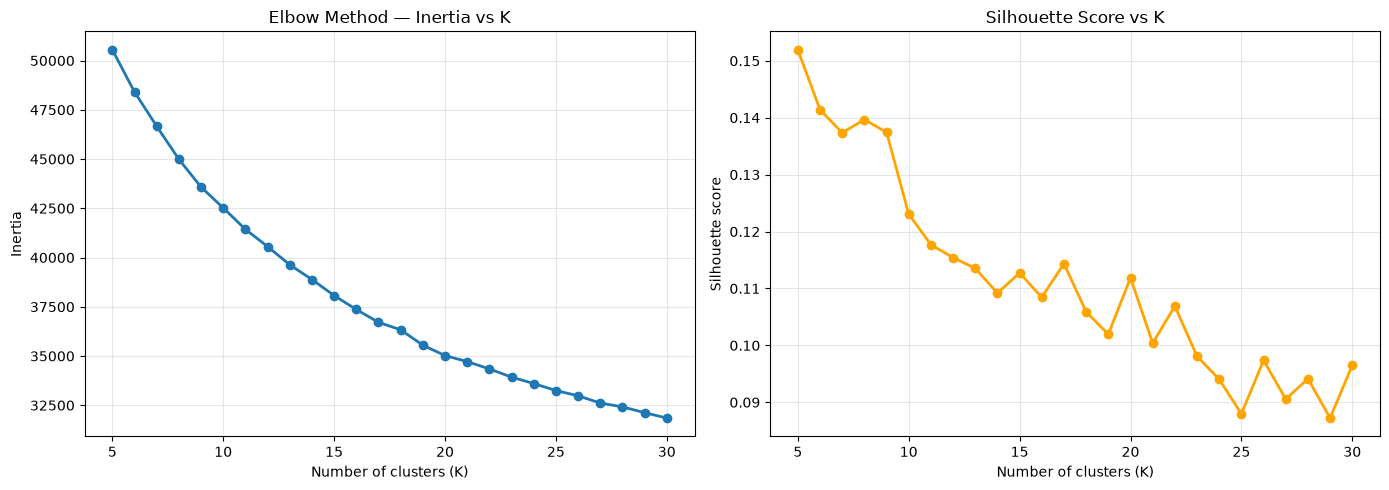

Plot saved to ../data/cluster_selection.png


In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(5, 31)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    print(f"  K={k:2d}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

# --- Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, marker='o', linewidth=2)
ax1.set_title('Elbow Method — Inertia vs K')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, marker='o', linewidth=2, color='orange')
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ../data/cluster_selection.png")

### K selection

The elbow flattens around K=8–10. The silhouette score peaks at K=5 (trivially large groups — essentially positional buckets) with a secondary peak at K=8–9. K=10 sits at that secondary peak with two additional archetypes over K=8 at negligible silhouette cost, and gives enough clusters to distinguish meaningful sub-archetypes (e.g. deep-lying playmaker vs box-to-box midfielder) without over-fragmenting.

**Selected: K=10**

In [13]:
K = 10

final_km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = final_km.fit_predict(X_scaled)

profiles['cluster'] = cluster_labels

print(f"K-Means fitted — K={K}")
print()
print("Players per cluster:")
print(profiles['cluster'].value_counts().sort_index().to_string())

K-Means fitted — K=10

Players per cluster:
cluster
0    247
1    610
2    546
3    634
4    253
5    730
6     91
7    871
8    320
9    173


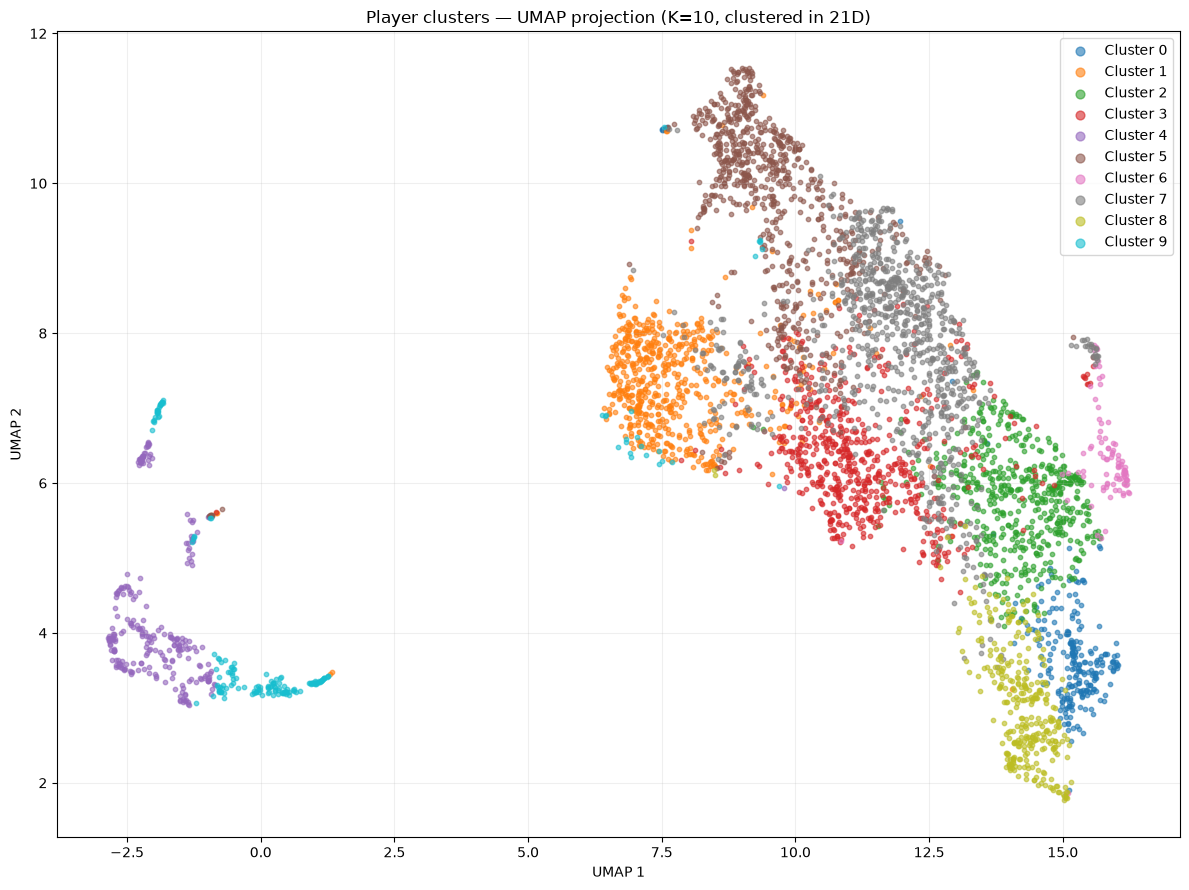

Plot saved to ../data/umap_clusters.png


In [14]:
import umap

# UMAP is for visualisation only — clusters are defined by K-Means in 21D space
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_2d = reducer.fit_transform(X_scaled)

profiles['umap_x'] = X_2d[:, 0]
profiles['umap_y'] = X_2d[:, 1]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 9))

colors = plt.cm.tab10.colors
for cluster_id in sorted(profiles['cluster'].unique()):
    mask = profiles['cluster'] == cluster_id
    ax.scatter(
        profiles.loc[mask, 'umap_x'],
        profiles.loc[mask, 'umap_y'],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}',
        s=10, alpha=0.6,
    )

ax.set_title('Player clusters — UMAP projection (K=10, clustered in 21D)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=2, loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../data/umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ../data/umap_clusters.png")

In [15]:
# Sense-check: print the top distinguishing features per cluster and sample players
print("=== Cluster profiles — top distinguishing features ===\n")

cluster_means  = profiles.groupby('cluster')[FEATURE_COLS].mean()
global_means   = profiles[FEATURE_COLS].mean()

for cluster_id in sorted(profiles['cluster'].unique()):
    row = cluster_means.loc[cluster_id]
    deviation = (row - global_means).abs().sort_values(ascending=False)
    top_features = deviation.head(5).index.tolist()

    size = (profiles['cluster'] == cluster_id).sum()
    print(f"--- Cluster {cluster_id}  ({size} players) ---")
    for f in top_features:
        direction = '▲' if row[f] > global_means[f] else '▼'
        print(f"  {direction} {f:<35s}  cluster={row[f]:+.3f}  global={global_means[f]:+.3f}")

    # Sample 5 players with the most minutes in this cluster
    sample = (profiles[profiles['cluster'] == cluster_id]
              .nlargest(5, 'minutes_played')[['player_name', 'team_name', 'minutes_played']])
    print(f"  Sample players:")
    for _, p in sample.iterrows():
        print(f"    {p['player_name']} ({p['team_name']}, {int(p['minutes_played'])} min)")
    print()

=== Cluster profiles — top distinguishing features ===

--- Cluster 0  (247 players) ---
  ▼ avg_pass_distance                    cluster=+15.966  global=+22.018
  ▼ long_balls_p90                       cluster=+2.216  global=+6.430
  ▼ progressive_passes_p90               cluster=+3.347  global=+6.381
  ▲ shots_p90                            cluster=+2.831  global=+1.022
  ▲ box_touches_p90                      cluster=+1.701  global=+0.000
  Sample players:
    Luis Alberto Suárez Díaz (Barcelona, 15650 min)
    Antoine Griezmann (Atlético Madrid, 9058 min)
    Thierry Henry (Arsenal, 7953 min)
    Alexis Alejandro Sánchez Sánchez (Arsenal, 7488 min)
    Samuel Eto''o Fils (Barcelona, 6719 min)

--- Cluster 1  (610 players) ---
  ▼ progressive_passes_p90               cluster=+4.603  global=+6.381
  ▼ long_balls_p90                       cluster=+5.382  global=+6.430
  ▼ carries_final_third_p90              cluster=+0.345  global=+1.279
  ▼ progressive_carries_p90              cluste

In [16]:
# Save final clustered profiles (includes cluster label and UMAP coords)
profiles.to_csv('../data/player_profiles_clustered.csv', index=False)
print(f"Saved player_profiles_clustered.csv — {len(profiles):,} players, {profiles.shape[1]} columns")
print(f"Columns: {list(profiles.columns)}")

Saved player_profiles_clustered.csv — 4,475 players, 29 columns
Columns: ['player_id', 'player_name', 'team_name', 'era', 'minutes_played', 'pass_completion_pct', 'progressive_passes_p90', 'pct_passes_forward', 'pct_passes_sideways', 'pct_passes_backward', 'avg_pass_distance', 'key_passes_p90', 'crosses_p90', 'long_balls_p90', 'pressures_p90', 'pressure_success_rate', 'tackles_p90', 'interceptions_p90', 'aerial_duels_p90', 'progressive_carries_p90', 'dribble_success_rate', 'carries_final_third_p90', 'xg_p90', 'xg_per_shot', 'shots_p90', 'box_touches_p90', 'cluster', 'umap_x', 'umap_y']


In [17]:
CLUSTER_LABELS = {
    0: 'Clinical Forwards',
    1: 'Low-Block Defenders',
    2: 'Creative Dribblers',
    3: 'Attacking Fullbacks',
    4: 'Goalkeepers',
    5: 'Ball-Playing Centre-Backs',
    6: 'Box-to-Box Midfielders',
    7: 'Press-Resistant Technical Midfielders',
    8: 'Physical Forwards',
    9: 'Goalkeepers (Ball-Playing)',
}

profiles['cluster_label'] = profiles['cluster'].map(CLUSTER_LABELS)

profiles.to_csv('../data/player_profiles_clustered.csv', index=False)
print(f"Saved — {len(profiles):,} players, {profiles.shape[1]} columns")
print()

sample = (
    profiles[['player_name', 'team_name', 'minutes_played', 'cluster', 'cluster_label']]
    .sample(10, random_state=7)
    .sort_values('cluster')
    .reset_index(drop=True)
)
print(sample.to_string(index=False))


Saved — 4,475 players, 30 columns

           player_name       team_name  minutes_played  cluster              cluster_label
   Ernesto Galán Iñigo        Espanyol            92.0        1        Low-Block Defenders
   Keven Schlotterbeck          Bochum           188.0        1        Low-Block Defenders
        Deepak Devrani      Chennaiyin           377.0        1        Low-Block Defenders
     Noussair Mazraoui   Bayern Munich           133.0        2         Creative Dribblers
    Waldo Rubio Martín Real Valladolid           117.0        2         Creative Dribblers
Nwankwo Christian Kanu         Arsenal           449.0        2         Creative Dribblers
         Marcel Heller    Darmstadt 98           187.0        3        Attacking Fullbacks
     Jerry Lalrinzuala      Chennaiyin          1566.0        3        Attacking Fullbacks
       Debjit Majumder      Chennaiyin           854.0        4                Goalkeepers
           Lee Carsley         Everton            93.0 